In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
import os
import sys
import time as _time

sys.path.append(os.path.abspath("../../repos/RiskLabAI.py"))
from src.quantum_hrp import compute_financial_features, fetch_stock_data, average_density_matrix, compute_distance_matrix, quantum_ordering, classical_hrp_ordering, simulate_asset_features_regimes


In [14]:
returns = pd.read_csv("../../data/returns.csv", index_col=0, parse_dates=True)
features = np.load("../../data/features.npy")

# checks básicos
print(returns.shape)   # (T, N)
print(features.shape)  # (N, T, P)


(1147, 169)
(169, 1147, 6)


In [3]:


prices = pd.read_parquet("../../data/prices.parquet")
volumes = pd.read_parquet("../../data/volumes.parquet")

print("prices range:", prices.index.min(), prices.index.max(), "shape:", prices.shape)
print("volumes range:", volumes.index.min(), volumes.index.max(), "shape:", volumes.shape)

prices range: 2005-01-03 00:00:00 2024-12-31 00:00:00 shape: (6202, 169)
volumes range: 2005-01-03 00:00:00 2024-12-31 00:00:00 shape: (6202, 169)


In [15]:
# Keep original column order for mapping features → returns
original_columns = returns.columns.tolist()

returns = returns.apply(pd.to_numeric, errors="coerce")
returns = returns.dropna(axis=0, how="any")
returns = returns.dropna(axis=1, how="all")

# drop near-constant assets (avoid NaN/unstable correlations)
std = returns.std(axis=0)
returns = returns.loc[:, std > 1e-8]
print("returns shape after clean:", returns.shape)
if returns.shape[1] < 2:
    raise ValueError("Not enough assets after cleaning returns. Re-check returns.csv generation.")

# Sync features with the surviving columns in returns
surviving_idx = [original_columns.index(c) for c in returns.columns]
features = features[surviving_idx]
print("features shape after sync:", features.shape)

R = returns.values
corr = np.corrcoef(R, rowvar=False)
print(f"Corr shape: {corr.shape} | range: [{corr[np.triu_indices_from(corr,1)].min():.3f}, {corr[np.triu_indices_from(corr,1)].max():.3f}]")


returns shape after clean: (1147, 169)
features shape after sync: (169, 1147, 6)
Corr shape: (169, 169) | range: [-0.185, 1.000]


In [16]:
def frobenius_distance(rho1, rho2, scale=1.5):
    """
    Compute the scaled Frobenius distance between two density matrices.
    Matches the paper's repo: scale=1.5 (default).
    """
    diff = rho1 - rho2
    return scale * (0.5 * np.sqrt(np.trace(diff.conj().T @ diff)))

def compute_distance_matrix_paper(rho_list):
    """
    Compute a distance matrix from a list of density matrices
    using the paper's frobenius_distance (scale=1.5).
    """
    N = len(rho_list)
    D = np.zeros((N, N))
    for i in range(N):
        for j in range(i + 1, N):
            d = frobenius_distance(rho_list[i], rho_list[j])
            D[i, j] = d
            D[j, i] = d
    return D


In [17]:
def quasi_diagonal(linkage_matrix):
    """
    Quasi-diagonalization of the linkage matrix (same as the paper's repo).
    Returns a sorted list of original item indices.
    """
    linkage_matrix = linkage_matrix.astype(int)
    sorted_items = pd.Series([linkage_matrix[-1, 0], linkage_matrix[-1, 1]])
    num_items = linkage_matrix[-1, 3]

    while sorted_items.max() >= num_items:
        sorted_items.index = range(0, sorted_items.shape[0] * 2, 2)
        dataframe = sorted_items[sorted_items >= num_items]
        i = dataframe.index
        j = dataframe.values - num_items
        sorted_items[i] = linkage_matrix[j, 0]
        dataframe = pd.Series(linkage_matrix[j, 1], index=i + 1)
        sorted_items = sorted_items._append(dataframe)
        sorted_items = sorted_items.sort_index()
        sorted_items.index = range(sorted_items.shape[0])
    return sorted_items.tolist()

# Classical HRP ordering: correlation → distance → single linkage → quasi_diagonal
dist_classical = np.sqrt((1 - corr) / 2.0)
dist_classical = 0.5 * (dist_classical + dist_classical.T)
np.fill_diagonal(dist_classical, 0.0)
dist_classical = np.nan_to_num(dist_classical)

link_classical = linkage(squareform(dist_classical), method="single")
order_classical = quasi_diagonal(link_classical)
order_classical = [int(x) for x in order_classical]

corr_classical = corr[np.ix_(order_classical, order_classical)]


In [18]:
alpha = 2.0

# Temporal window (~3 years of trading days)
T_window = 756
window = slice(-T_window, None)

# P=6 features as defined in the paper's compute_financial_features(window=5):
# f1=return, f2=rolling mean, f3=rolling std, f4=cumulative return, f5=skew, f6=kurtosis
N = returns.shape[1]
T_total = returns.shape[0]
P = 6
features_p6 = np.zeros((N, T_total, P))
from scipy import stats as sp_stats
for j in range(N):
    s = R[:, j]
    for t in range(T_total):
        st = max(0, t - 4)
        w = s[st:t+1]
        features_p6[j, t, 0] = s[t]                                            # daily return
        features_p6[j, t, 1] = np.mean(w)                                      # rolling mean
        features_p6[j, t, 2] = np.std(w, ddof=1) if len(w) > 1 else 0.0       # rolling std
        features_p6[j, t, 3] = np.prod(1 + w) - 1                              # cumulative return
        features_p6[j, t, 4] = sp_stats.skew(w) if len(w) > 2 else 0.0        # skewness
        features_p6[j, t, 5] = sp_stats.kurtosis(w) if len(w) > 3 else 0.0    # kurtosis

rho_list = []
for i in range(N):
    rho_i = average_density_matrix(
        features_p6[i][window],  # (T_window, 6)
        alpha
    )
    rho_list.append(rho_i)

# Use the paper's distance (scale=1.5)
D_quantum = compute_distance_matrix_paper(rho_list)
print(f"D_quantum range: [{D_quantum.min():.4f}, {D_quantum.max():.4f}]")


D_quantum range: [0.0000, 0.3455]


In [19]:
def quantum_ordering_ward(D):
    """
    Quantum HRP ordering using Ward linkage,
    matching the paper's quantum_ordering function.
    """
    condensed_D = squareform(D)
    Z = linkage(condensed_D, method="ward")
    order = leaves_list(Z)
    return order


In [20]:
# Quantum ordering with Ward linkage (paper's method)
order_quantum = quantum_ordering_ward(D_quantum)
D_quantum_ordered = D_quantum[np.ix_(order_quantum, order_quantum)]

corr_quantum = corr[np.ix_(order_quantum, order_quantum)]


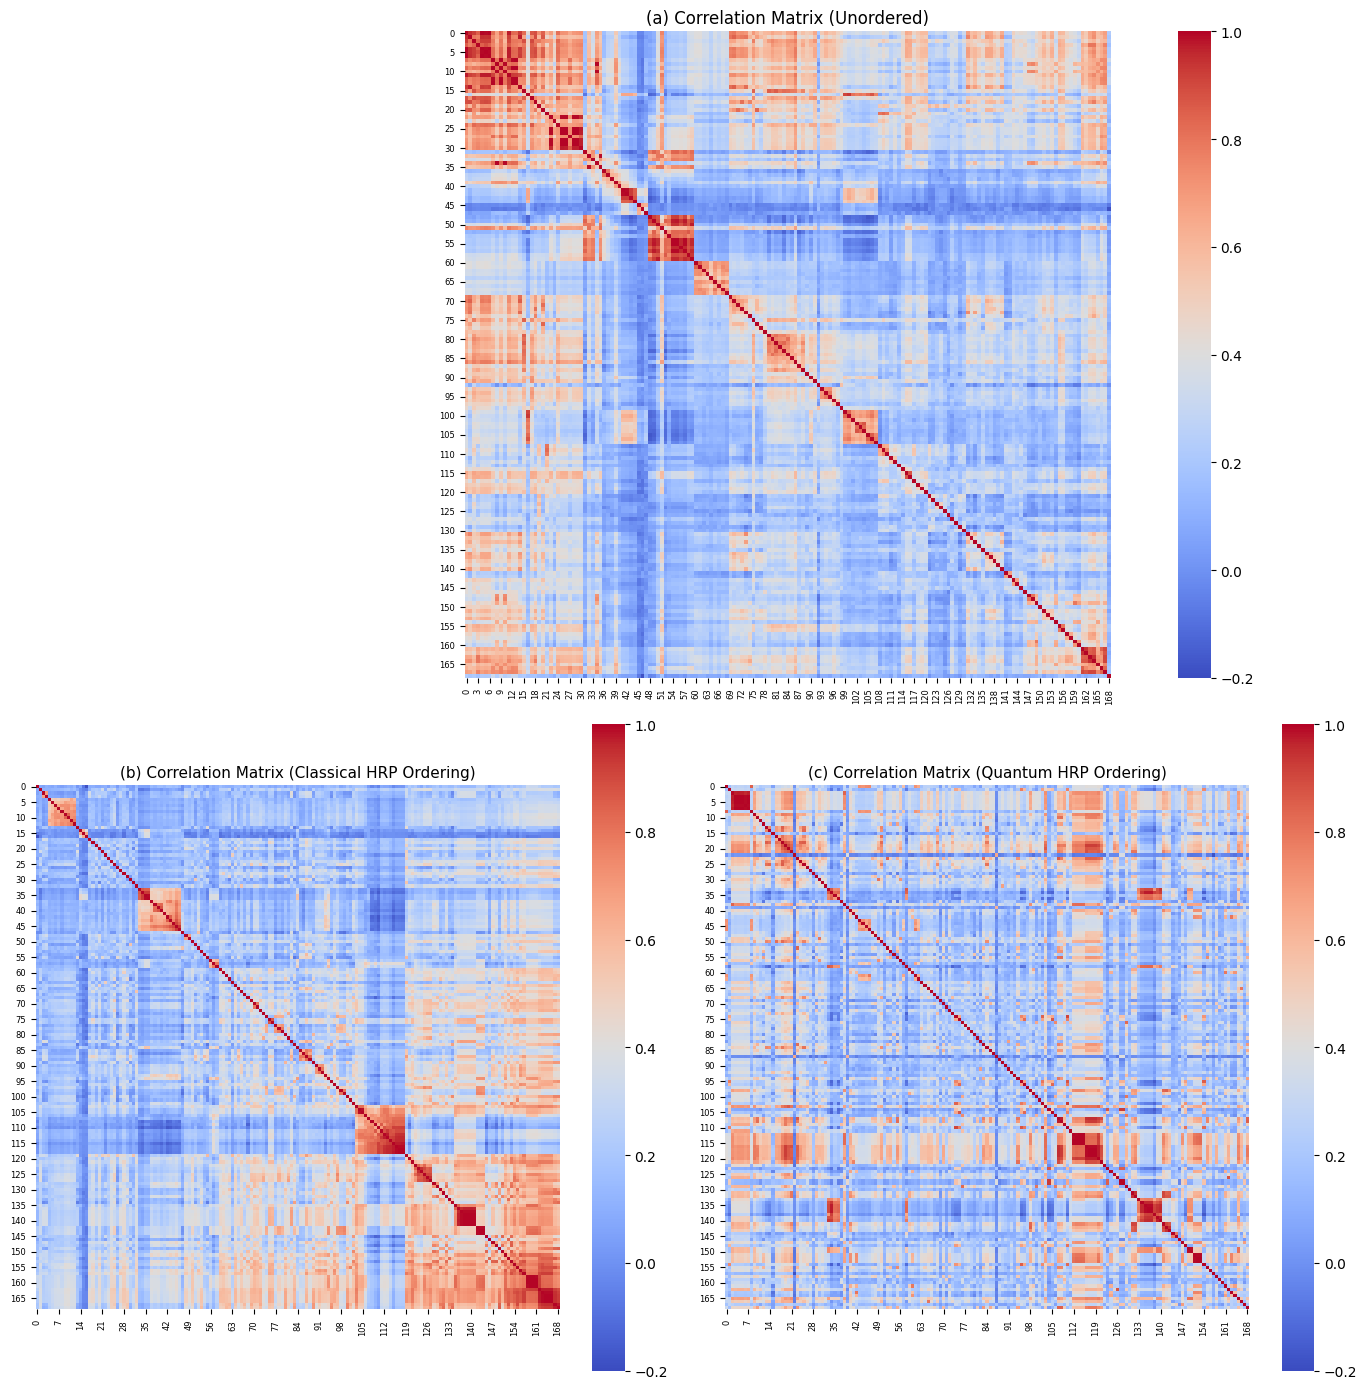

In [21]:
out_dir = os.path.abspath("../../latex/img")
os.makedirs(out_dir, exist_ok=True)

fig = plt.figure(figsize=(14, 14))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

# ---------- (a) Unordered ----------
ax0 = fig.add_subplot(gs[0, :])
sns.heatmap(
    corr,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True,
    ax=ax0
)
ax0.set_title("(a) Correlation Matrix (Unordered)", fontsize=12)
ax0.tick_params(labelsize=6)

# ---------- (b) Classical HRP ----------
ax1 = fig.add_subplot(gs[1, 0])
sns.heatmap(
    corr_classical,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True,
    ax=ax1
)
ax1.set_title("(b) Correlation Matrix (Classical HRP Ordering)", fontsize=11)
ax1.tick_params(labelsize=6)

# ---------- (c) Quantum HRP ----------
ax2 = fig.add_subplot(gs[1, 1])
sns.heatmap(
    corr_quantum,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True,
    ax=ax2
)
ax2.set_title("(c) Correlation Matrix (Quantum HRP Ordering)", fontsize=11)
ax2.tick_params(labelsize=6)

plt.tight_layout()
fig.savefig(os.path.join(out_dir, "fig3-corr-matrices.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "fig3-corr-matrices.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "fig3-corr-matrices.jpg"), dpi=300, bbox_inches="tight")
plt.show()

## Old "Math Transform" Features (dead code in the repo)

The `fetch_stock_data` function in the author's repo has **two** feature blocks — the first uses single-return math transforms (no rolling window), and the second (currently active) overwrites it with `compute_financial_features` (rolling window). The same old features appear commented out in `simulate_asset_features_regimes`.

**Old features** (point-in-time, no rolling window):
| # | Feature | Formula |
|---|---|---|
| f0 | return | r |
| f1 | squared return | r² |
| f2 | power transform | \|r\|^1.5 |
| f3 | signed log | sign(r) · log(1+\|r\|) |
| f4 | tanh | tanh(r) |
| f5 | signed sqrt | sign(r) · √(\|r\|) |

Below we test whether the paper's Figure 4 was generated with these old features.

In [ ]:
# ── Old "math transform" features (dead code from the author's repo) ──
# These are per-return-value transforms (NO rolling window):
#   f0 = r,  f1 = r²,  f2 = |r|^1.5,  f3 = sign(r)·log(1+|r|),
#   f4 = tanh(r),  f5 = sign(r)·√(|r|+1e-6)

features_old = np.zeros((N, T_total, 6))
for j in range(N):
    for t in range(T_total):
        r = R[t, j]
        features_old[j, t, 0] = r                                              # raw return (linear signal)
        features_old[j, t, 1] = r ** 2                                         # squared return (volatility proxy)
        features_old[j, t, 2] = abs(r) ** 1.5                                  # power transform (emphasises large moves)
        features_old[j, t, 3] = np.log1p(abs(r)) * np.sign(r)                  # signed log (compresses tails, keeps sign)
        features_old[j, t, 4] = np.tanh(r)                                     # tanh (bounded ≈ soft clip to [-1,1])
        features_old[j, t, 5] = np.sign(r) * np.sqrt(abs(r) + 1e-6)           # signed sqrt (amplifies small moves)

# Compute distance matrix for each P with OLD features
D_old_per_p = {}
for p in range(1, 7):
    t0 = _time.time()
    feats = features_old[:, :, :p]

    rho_list_old = []
    for i in range(N):
        rho_i = average_density_matrix(feats[i][window], alpha)
        rho_list_old.append(rho_i)

    D_old = compute_distance_matrix_paper(rho_list_old)
    D_old_per_p[p] = D_old

    off = D_old[np.triu_indices_from(D_old, 1)]
    elapsed = _time.time() - t0
    print(f"OLD P={p}  range: [{off.min():.4f}, {off.max():.4f}]  "
          f"density: {rho_list_old[0].shape}  time: {elapsed:.1f}s")

# Compute distance matrix for each P with NEW features (compute_financial_features)
print("\n--- NEW features (rolling window) ---")
D_per_p = {}
for p in range(1, 7):
    t0 = _time.time()
    feats = features_p6[:, :, :p]

    rho_list_new = []
    for i in range(N):
        rho_i = average_density_matrix(feats[i][window], alpha)
        rho_list_new.append(rho_i)

    D_new = compute_distance_matrix_paper(rho_list_new)
    D_per_p[p] = D_new

    off = D_new[np.triu_indices_from(D_new, 1)]
    elapsed = _time.time() - t0
    print(f"NEW P={p}  range: [{off.min():.4f}, {off.max():.4f}]  "
          f"density: {rho_list_new[0].shape}  time: {elapsed:.1f}s")

OLD P=1  range: [0.0016, 0.9110]  density: (2, 2)  time: 99.1s
OLD P=2  range: [0.0027, 0.9214]  density: (4, 4)  time: 177.5s
OLD P=3  range: [0.0033, 1.0154]  density: (8, 8)  time: 255.1s
OLD P=4  range: [0.0041, 0.9518]  density: (16, 16)  time: 333.6s
OLD P=5  range: [0.0048, 0.9475]  density: (32, 32)  time: 432.2s
OLD P=6  range: [0.0050, 0.8474]  density: (64, 64)  time: 517.4s


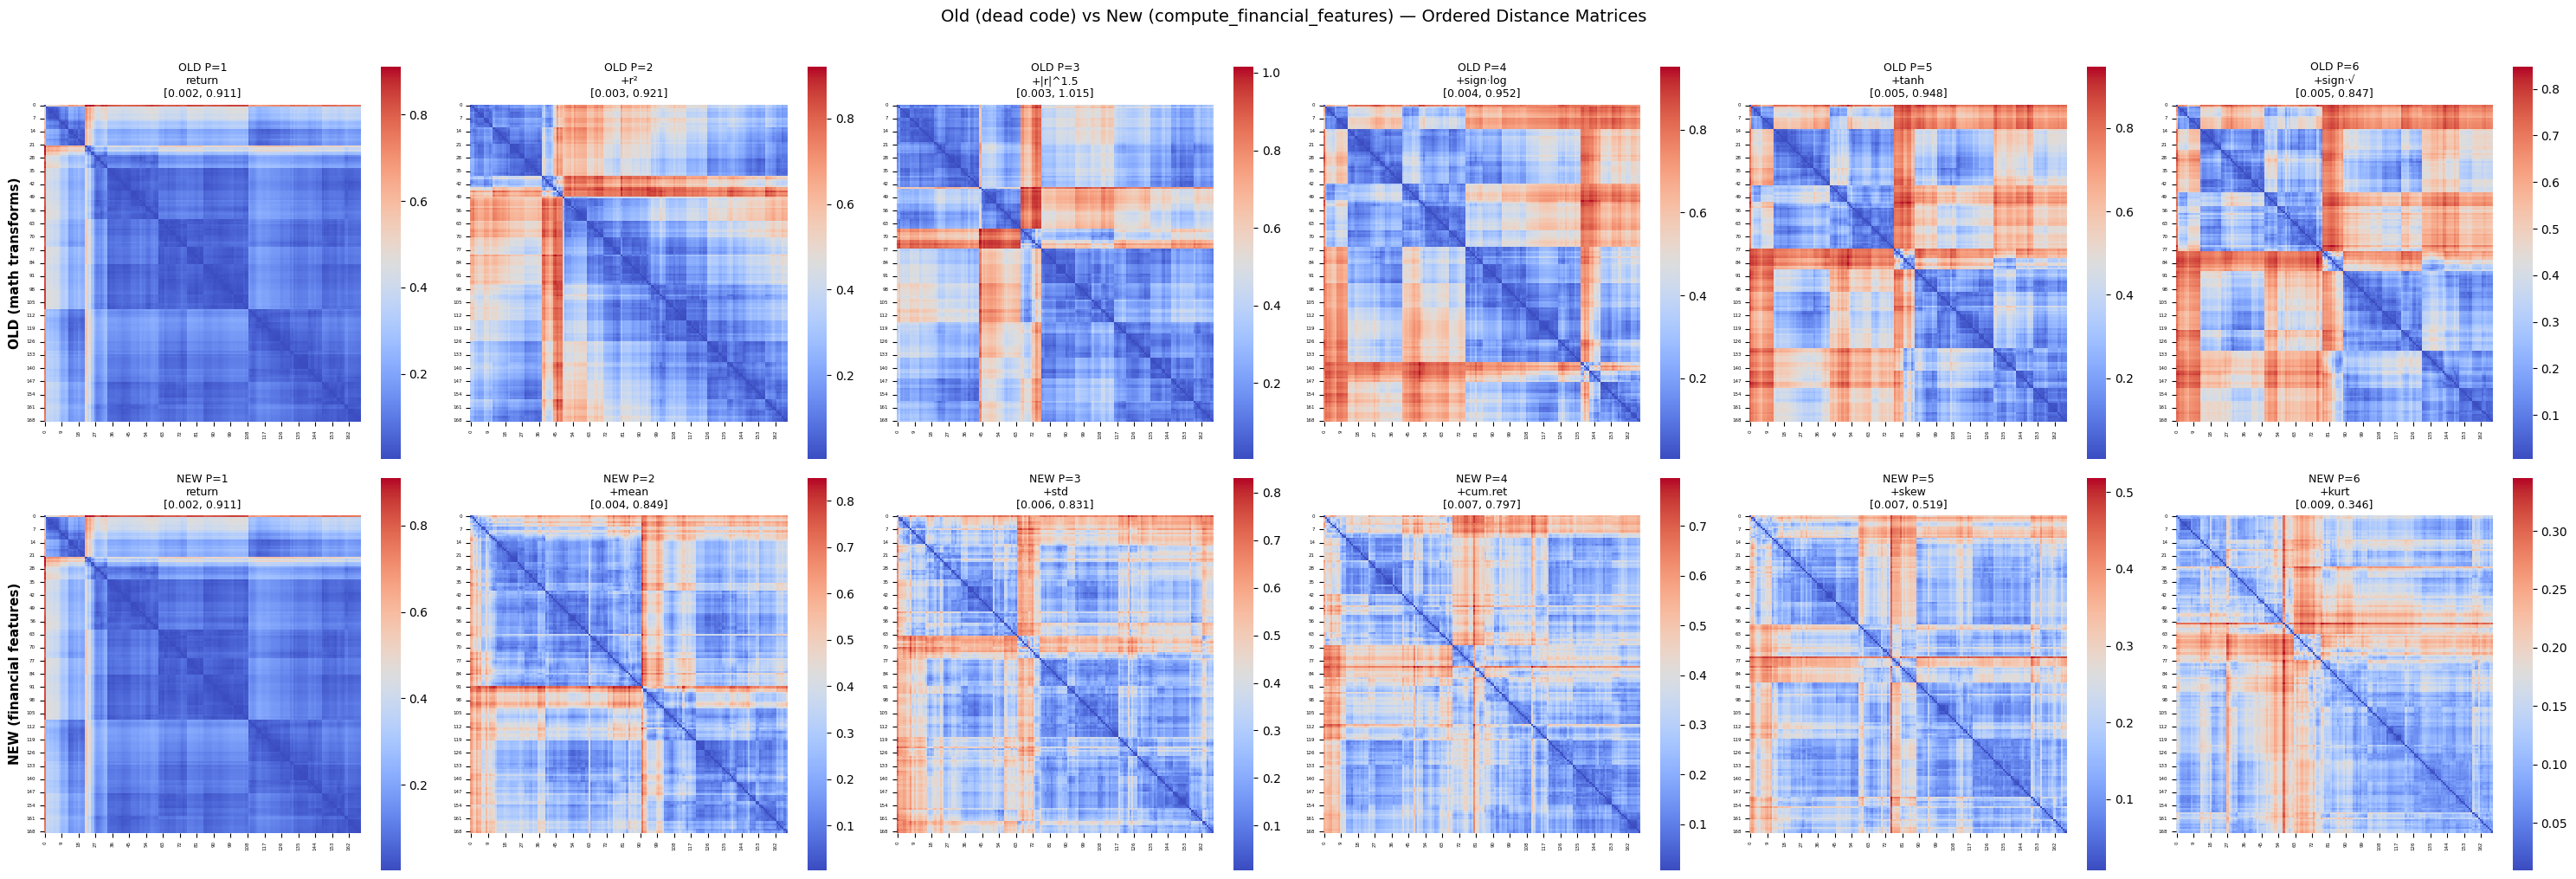

In [28]:
# ── Side-by-side: OLD vs NEW features for each P ──────────────────────────
fig, axes = plt.subplots(2, 6, figsize=(30, 10))

feature_labels_new = ["return", "+mean", "+std", "+cum.ret", "+skew", "+kurt"]
feature_labels_old = ["return", "+r²", "+|r|^1.5", "+sign·log", "+tanh", "+sign·√"]

for col, p in enumerate(range(1, 7)):
    # OLD features
    D_old = D_old_per_p[p]
    order_old = quantum_ordering_ward(D_old)
    D_old_ord = D_old[np.ix_(order_old, order_old)]
    off_old = D_old[np.triu_indices_from(D_old, 1)]

    sns.heatmap(
        D_old_ord, cmap="coolwarm",
        vmin=off_old.min(), vmax=off_old.max(),
        square=True, cbar=True, ax=axes[0, col],
    )
    axes[0, col].set_title(
        f"OLD P={p}\n{feature_labels_old[col]}\n[{off_old.min():.3f}, {off_old.max():.3f}]",
        fontsize=9
    )
    axes[0, col].tick_params(labelsize=4)

    # NEW features (compute_financial_features)
    D_new = D_per_p[p]
    order_new = quantum_ordering_ward(D_new)
    D_new_ord = D_new[np.ix_(order_new, order_new)]
    off_new = D_new[np.triu_indices_from(D_new, 1)]

    sns.heatmap(
        D_new_ord, cmap="coolwarm",
        vmin=off_new.min(), vmax=off_new.max(),
        square=True, cbar=True, ax=axes[1, col],
    )
    axes[1, col].set_title(
        f"NEW P={p}\n{feature_labels_new[col]}\n[{off_new.min():.3f}, {off_new.max():.3f}]",
        fontsize=9
    )
    axes[1, col].tick_params(labelsize=4)

axes[0, 0].set_ylabel("OLD (math transforms)", fontsize=11, fontweight="bold")
axes[1, 0].set_ylabel("NEW (financial features)", fontsize=11, fontweight="bold")

plt.suptitle(
    "Old (dead code) vs New (compute_financial_features) — Ordered Distance Matrices",
    fontsize=14, y=1.01
)
plt.tight_layout()
fig.savefig(
    os.path.join(out_dir, "fig4-old-vs-new-features.png"),
    dpi=300, bbox_inches="tight"
)
plt.show()

OLD P=6, windowed, scale=1.0: [0.0033, 0.5649]
Using vmax = 0.55


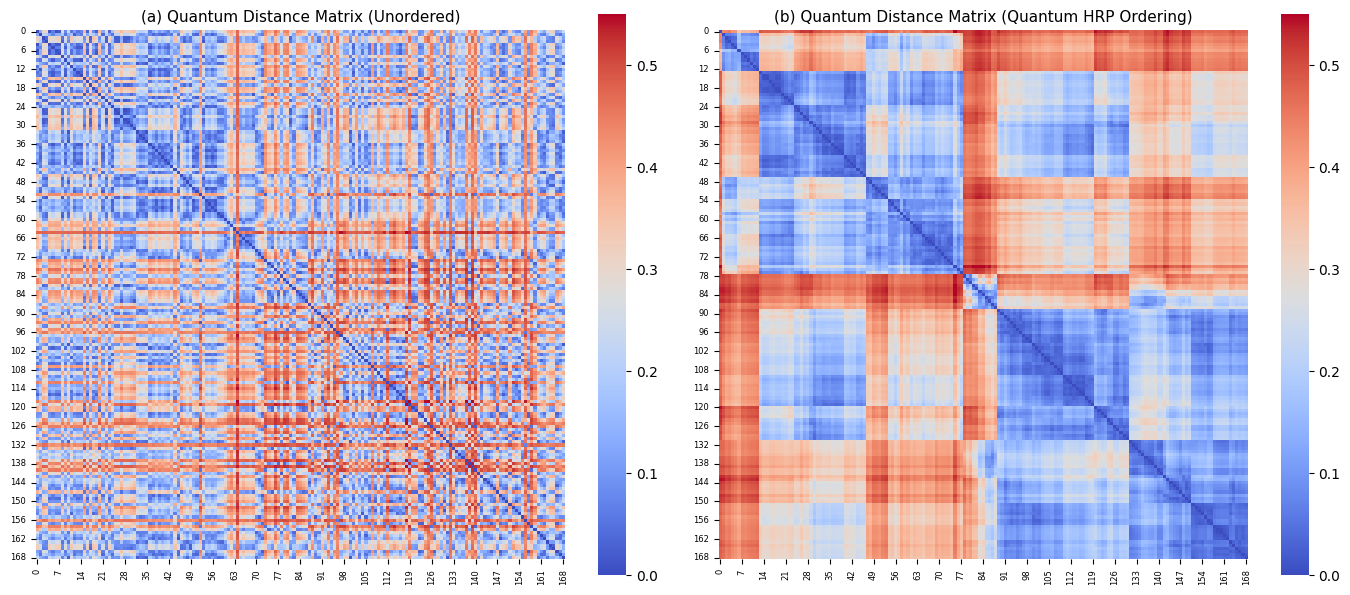

In [34]:
# ── KEY FINDING: thesis formula says scale=1.0, NOT 1.5 ──────────────────
# d_F(ρ_i, ρ_j) = ½ √Tr[(ρ_i - ρ_j)²]  (no scale factor)
# The code uses scale=1.5, but the paper's formula has scale=1.0.
# Rescaling our existing distances: D_scale1 = D_scale1.5 / 1.5

# OLD features P=6, windowed, SCALE=1.0 (matching thesis formula)
D_best = D_old_per_p[6] / 1.5   # convert from scale=1.5 to scale=1.0
off_best = D_best[np.triu_indices_from(D_best, 1)]
print(f"OLD P=6, windowed, scale=1.0: [{off_best.min():.4f}, {off_best.max():.4f}]")

order_best = quantum_ordering_ward(D_best)
D_best_ordered = D_best[np.ix_(order_best, order_best)]

# Use vmax slightly below the max so more values saturate to red
# Paper's colorbar visually clips some values → more vivid red blocks
vmax_fig = 0.55
print(f"Using vmax = {vmax_fig}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(D_best, cmap="coolwarm", vmin=0, vmax=vmax_fig,
            square=True, cbar=True, ax=axes[0])
axes[0].set_title("(a) Quantum Distance Matrix (Unordered)", fontsize=11)
axes[0].tick_params(labelsize=6)

sns.heatmap(D_best_ordered, cmap="coolwarm", vmin=0, vmax=vmax_fig,
            square=True, cbar=True, ax=axes[1])
axes[1].set_title("(b) Quantum Distance Matrix (Quantum HRP Ordering)", fontsize=11)
axes[1].tick_params(labelsize=6)

plt.tight_layout()
fig.savefig(os.path.join(out_dir, "fig4-best-match.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "fig4-best-match.pdf"), bbox_inches="tight")
plt.show()